In [11]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import *
import pandas as pd
import os
new_data = np.linspace(0, 1, 1000) 
seed = 42
args = {"max_leaf_nodes": 5}


In [12]:
####### Simulation parameters  
n_sim = 2000
n = 500
B = 100                                                #  <--------- number of bootstrap samples
folder_name = f"UNweighted_n500_B100_nsim2000"     # <--------- folder name for results
std_estimator_name = "IJ-U"                           # <--------- name of the estimator
fixed_x = False
weighted_boot_samples = False
ij_variance_calc = True
ij_w_variance_calc = False

In [13]:
# run sim and save results
n_pred = new_data.shape[0]
####### sim description ############################
text = f"n={n}, B={B}, seed={seed}, max_leaf_nodes={args['max_leaf_nodes']}, n_pred={n_pred} und {n_sim} Simulationen."

def make_folder(text,folder_name):
    folder_name2 = folder_name
    if not os.path.exists("./results/" + folder_name2):
        os.makedirs("./results/" + folder_name2)
    with open("./results/" + folder_name2 + "/readme.txt", "w") as f:
        f.write(text)
        
make_folder(text,folder_name)

# data and weights for X
rng = np.random.default_rng(seed)
weights = np.zeros(n)
weights += 1 / int(n/2)
index_drop = rng.choice(range(n), size=int(n/2), replace=False)
weights[index_drop] = 0.0

if weighted_boot_samples:
    boot_weights = weights.copy()
else:
    boot_weights = None


# run sim and save results
with ProcessPoolExecutor() as executor:
    
    bagged_preds = np.zeros((n_sim, new_data.shape[0]))
    biased_var_estimates = np.zeros((n_sim, new_data.shape[0]))
    bias_corrections = np.zeros((n_sim, new_data.shape[0]))
    
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
                n = n,
                B = B,
                new_data = new_data,
                simulation_index = i,
                seed = seed,
                dt_args = args,
                boot_weights = boot_weights,            # <--------- ungewichtete boot-samples erzeugen = None
                ij_variance_calc = ij_variance_calc,
                ij_w_variance_calc = ij_w_variance_calc,
                fixed_x = fixed_x
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds[i, :] = bagged_prediction
        biased_var_estimates[i, :] = biased_var_estimate
        bias_corrections[i, :] = bias_correction

# save results
np.save(f"./results/{folder_name}/bagged_preds.npy", bagged_preds)
np.save(f"./results/{folder_name}/biased_var_estimates.npy", biased_var_estimates)
np.save(f"./results/{folder_name}/bias_var_corrections.npy", bias_corrections)


Simulations: 100%|██████████| 2000/2000 [00:39<00:00, 51.21simulation/s]


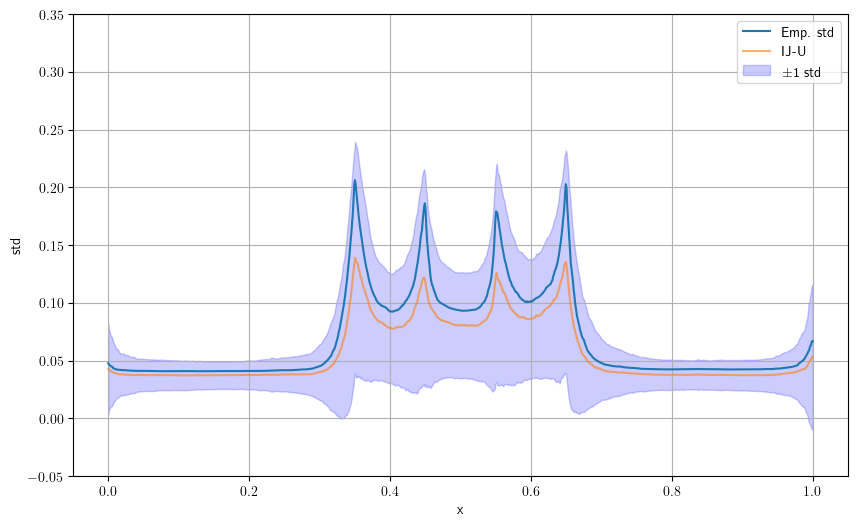

In [14]:
# plot results
bagged_preds = np.load(f"./results/{folder_name}/bagged_preds.npy")
biased_var_estimates = np.load(f"./results/{folder_name}/biased_var_estimates.npy")
bias_corrections = np.load(f"./results/{folder_name}/bias_var_corrections.npy")

save_results_png(
    new_data=new_data,
    std_estimator_name=std_estimator_name,
    bagged_preds=bagged_preds,
    est_vars_biased=biased_var_estimates,
    bias_correction=bias_corrections,
    folder_name=folder_name,
    y_lim=(-0.05, 0.35),
    show_only_plot=True,
)


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

def compare_emp_std_png(
    new_data: np.ndarray,
    folder1: str,
    folder2: str,
    filename: str = "emp_std_comparison.png",
    y_lim: Tuple[float, float] = (0, 0.35),
    show_only_plot: bool = False,
):
    # laden
    bp1 = np.load(f"./results/{folder1}/bagged_preds.npy")
    bp2 = np.load(f"./results/{folder2}/bagged_preds.npy")

    # empirische Standardabweichung (ddof=1 für unbiased)
    std1 = bp1.std(axis=0, ddof=1)
    std2 = bp2.std(axis=0, ddof=1)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(new_data, std1, label=f"Emp. std – {folder1}", lw=2)
    plt.plot(new_data, std2, label=f"Emp. std – {folder2}", lw=2)
    plt.xlabel("x")
    plt.ylabel("std")
    plt.ylim(y_lim)
    plt.grid(True)
    plt.legend(['emp. std - based on weighted bootstrap samples','emp. std - based on Unweighted bootstrap samples'])
    plt.tight_layout()

    if show_only_plot:
        plt.show()
    else:
        out_dir = f"./results/{folder1}"
        os.makedirs(out_dir, exist_ok=True)
        plt.savefig(f"{out_dir}/{filename}", dpi=300, bbox_inches='tight')
        plt.close()

# Beispielaufruf:
compare_emp_std_png(
    new_data=new_data,
    folder1="UNweighted_n500_B100_nsim2000",
    folder2="weighted_n500_B100_nsim2000",
    filename="emp_std_comparison.png",
    y_lim=(0, 0.4),
    show_only_plot=False
)
